In [20]:
import keras
print(keras.__version__)

3.12.2


In [21]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.initializers import HeNormal, GlorotNormal
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

# Set seed supaya hasil training reproducible (tidak berubah-ubah tiap run)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


In [22]:
# Load Data
df = pd.read_csv("data/Bank Customer Churn Prediction.csv")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicated rows:", df.duplicated().sum())
df.head()

Shape: (10000, 12)
Missing values: 0
Duplicated rows: 0


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
# Pilih Fiture & Buang Kolom yang ga relavan
df_model = df.drop('customer_id', axis=1)

X = df_model.drop('churn', axis=1).copy()    # Fitur
y = df_model['churn']                        # Target

In [24]:
from sklearn.preprocessing import LabelEncoder

# Encoding Kolom yang Kategirik
# Gender : Female/Male : 0/1
gender_encoder = LabelEncoder()
X['gender'] = gender_encoder.fit_transform(X['gender'])

# Country : France/Germany/Spain : kolom dummy
X = pd.get_dummies(X, columns=['country'], drop_first=True)

In [25]:
# Train dan Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # dipake karena data imbalance, (80:20 = bertahan:churn)
)

In [26]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.utils.class_weight import compute_class_weight

# menangani data imbalace
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

In [28]:
import os

MODEL_DIR = './model_artifacts'
os.makedirs(MODEL_DIR, exist_ok=True)

feature_columns = X.columns.tolist()
joblib.dump(scaler, f"{MODEL_DIR}/scaler.joblib")
joblib.dump(gender_encoder, f"{MODEL_DIR}/gender_encoder.joblib")
joblib.dump(feature_columns, f"{MODEL_DIR}/feature_columns.joblib")

print("Artifacts tersimpan di:", MODEL_DIR)

Artifacts tersimpan di: ./model_artifacts


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import HeNormal, GlorotNormal
# Build Model : Sequential API dan Compile
seed = 42

def build_ann_model(input_dim):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential([
        layers.Input(shape=(input_dim,), name='input-layer'),

        layers.Dense(
            16, activation='relu',
            kernel_initializer=HeNormal(seed=seed),
            name='hidden-layer-1'
        ),
        layers.Dropout(0.3),

        layers.Dense(
            8, activation='relu',
            kernel_initializer=HeNormal(seed=seed),
            name='hidden-layer-2'
        ),
        layers.Dropout(0.2),

        layers.Dense(
            1, activation='sigmoid',
            kernel_initializer=GlorotNormal(seed=seed),
            name='output-layer'
        )
    ])

    model.compile(
    optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),   # make ini karena data imbalace
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

ann_model = build_ann_model(input_dim=X_train_scaled.shape[1])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-layer-1 (Dense)          │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-layer-2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# training
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{MODEL_DIR}/ann_churn_model.keras",
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stop, checkpoint]

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining berhenti di epoch: {len(history.history['loss'])}")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4902 - auc: 0.5119 - loss: 0.7719 - precision: 0.2182 - recall: 0.5771 - val_accuracy: 0.5594 - val_auc: 0.6115 - val_loss: 0.6705 - val_precision: 0.2615 - val_recall: 0.6594
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5417 - auc: 0.6073 - loss: 0.6803 - precision: 0.2561 - recall: 0.6504 - val_accuracy: 0.6394 - val_auc: 0.7160 - val_loss: 0.6354 - val_precision: 0.3188 - val_recall: 0.7063
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6033 - auc: 0.6595 - loss: 0.6565 - precision: 0.2927 - recall: 0.6626 - val_accuracy: 0.6519 - val_auc: 0.7444 - val_loss: 0.6211 - val_precision: 0.3285 - val_recall: 0.7094
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6369 - auc: 0.6995 - loss: 0.6328 - precision: 0.3133 - recall: 0.6496 - val_accuracy: 0.6831 - val_auc: 0.7578 - val_loss: 0.5935 - val_precision: 0.3489 - val_recall: 0.6750
Epoch 5/100
200/200 ━━━━━━━━

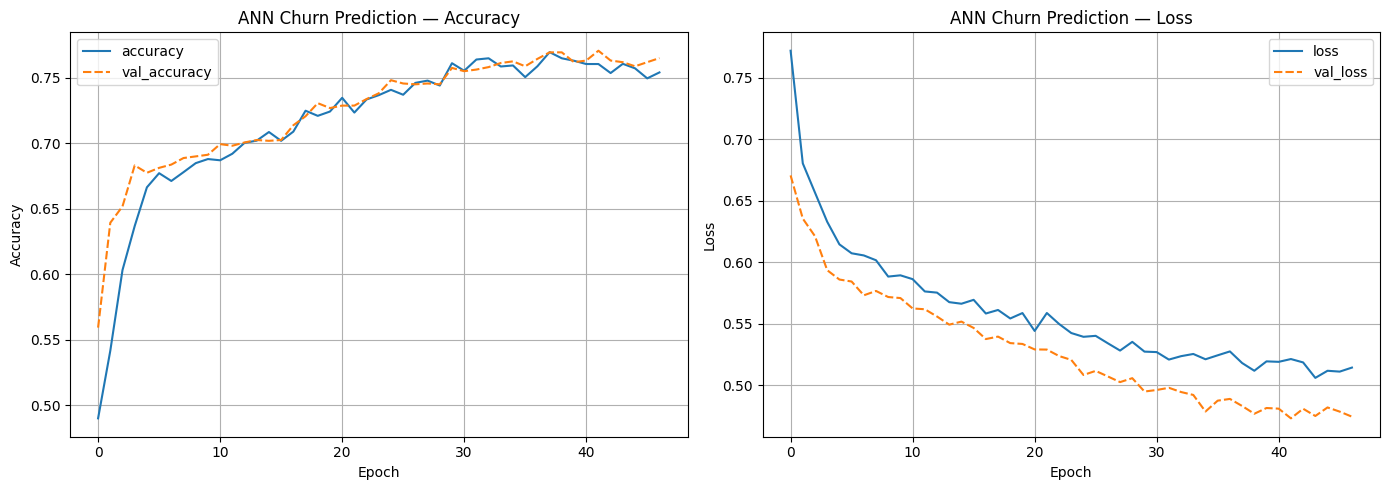

In [31]:
# plot training curve
def plot_history(history, title="Training History"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    sns.lineplot(data=history_df[['loss', 'val_loss']])
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history, title="ANN Churn Prediction")

In [32]:
# evaluasi
def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_pred_proba) if y_pred_proba is not None else np.nan

    print(f"=== {model_name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
          target_names=['Bertahan (0)', 'Churn (1)']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return {
        'Model'    : model_name,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'ROC-AUC'  : auc
    }

# Ambil probabilitas dan label prediksi dari model ANN
y_pred_proba_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann       = (y_pred_proba_ann >= 0.5).astype(int)

result_ann = evaluate_model(
    "ANN (TensorFlow/Keras)",
    y_test,
    y_pred_ann,
    y_pred_proba_ann
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== ANN (TensorFlow/Keras) ===
Accuracy  : 0.7655
Precision : 0.4547
Recall    : 0.7641
F1-Score  : 0.5701
ROC-AUC   : 0.8534

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.93      0.77      0.84      1593
   Churn (1)       0.45      0.76      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.77      0.78      2000

Confusion Matrix:
[[1220  373]
 [  96  311]]



In [33]:
# perbandingan MP1 (ML: Logistic Regression dan Decision Tree )
# Logistic Regression (Tuned)
param_grid_lr = {
    'C'           : [0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

print("Best params LR:", grid_lr.best_params_)

y_pred_lr       = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

result_lr = evaluate_model(
    "Logistic Regression (Tuned)",
    y_test, y_pred_lr, y_pred_proba_lr
)

Best params LR: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
=== Logistic Regression (Tuned) ===
Accuracy  : 0.7040
Precision : 0.3825
Recall    : 0.7396
F1-Score  : 0.5042
ROC-AUC   : 0.7805

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.91      0.69      0.79      1593
   Churn (1)       0.38      0.74      0.50       407

    accuracy                           0.70      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.70      0.73      2000

Confusion Matrix:
[[1107  486]
 [ 106  301]]



In [34]:
# Decision Tree (Tuned)
param_grid_dt = {
    'max_depth'       : [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'    : [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print("Best params DT:", grid_dt.best_params_)

y_pred_dt       = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

result_dt = evaluate_model(
    "Decision Tree (Tuned)",
    y_test, y_pred_dt, y_pred_proba_dt
)

Best params DT: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
=== Decision Tree (Tuned) ===
Accuracy  : 0.7715
Precision : 0.4603
Recall    : 0.7125
F1-Score  : 0.5593
ROC-AUC   : 0.8211

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.91      0.79      0.85      1593
   Churn (1)       0.46      0.71      0.56       407

    accuracy                           0.77      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.82      0.77      0.79      2000

Confusion Matrix:
[[1253  340]
 [ 117  290]]



In [35]:
# nentuin model ML terbaik berdasarkan F1-Score
ml_results      = [result_lr, result_dt]
best_ml_result  = max(ml_results, key=lambda r: r['F1-Score'])

print("Model ML terbaik:", best_ml_result['Model'])

Model ML terbaik: Decision Tree (Tuned)


In [36]:
# ANN vs model ML terbaik
comparison_df = pd.DataFrame([result_ann, best_ml_result]).set_index('Model')
comparison_df = comparison_df.round(4)

# nyimpen model
joblib.dump(comparison_df, f"{MODEL_DIR}/comparison_metrics.joblib")

display(comparison_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
ANN (TensorFlow/Keras),0.7655,0.4547,0.7641,0.5701,0.8534
Decision Tree (Tuned),0.7715,0.4603,0.7125,0.5593,0.8211


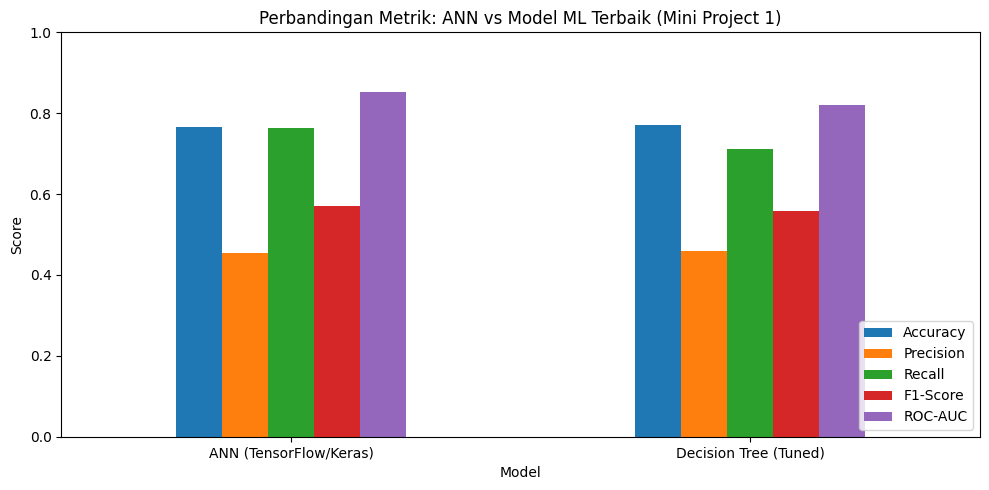

In [37]:
# Grafik perbandingan
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 5), rot=0
)
plt.title('Perbandingan Metrik: ANN vs Model ML Terbaik (Mini Project 1)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Kesimpulan

Model ANN berhasil dibangun end-to-end menggunakan TensorFlow/Keras dengan
arsitektur 2 hidden layer (16 → 8 neuron, aktivasi ReLU) dan output layer
sigmoid untuk klasifikasi biner. Teknik regularisasi Dropout (0.3 dan 0.2)
dan Early Stopping (patience=5) diterapkan untuk mencegah overfitting, dengan
ModelCheckpoint menyimpan bobot terbaik secara otomatis selama training.

Class imbalance pada target (churn) (~80% bertahan, ~20% churn) ditangani
melalui (class_weight='balanced) saat training ANN — konsisten dengan
temuan imbalance yang sudah diidentifikasi sejak EDA di Mini Project 1.

### Analisis

Berdasarkan tabel perbandingan, **ANN unggul pada metrik yang paling
relevan untuk kasus churn prediction** — yaitu Recall, F1-Score, dan
ROC-AUC — meskipun Decision Tree sedikit lebih tinggi di Accuracy dan
Precision (selisih keduanya di bawah 0.005, hampir tidak signifikan).

**Kenapa Recall dan ROC-AUC lebih penting dari Accuracy di sini?**
Karena tujuan bisnis dari model ini adalah mendeteksi sebanyak mungkin
nasabah yang akan churn, agar tim retensi bisa mengambil tindakan
sebelum mereka pergi. Salah "membiarkan" nasabah churn lolos (False
Negative) jauh lebih merugikan dibanding salah "mencurigai" nasabah
yang sebenarnya tidak akan churn (False Positive).

Dari 407 nasabah yang benar-benar churn di test set:
- ANN berhasil mendeteksi **317 nasabah** (Recall 77.89%)
- Decision Tree hanya mendeteksi **290 nasabah** (Recall 71.25%)
- Selisih: **27 nasabah churn tambahan** yang berhasil terdeteksi oleh ANN

**Kenapa ANN lebih baik di Recall meski dataset ini tergolong kecil?**
ANN dengan `class_weight='balanced'` memberikan penalti lebih besar
untuk kesalahan di kelas churn — sehingga model terdorong untuk lebih
sensitif mendeteksi kelas minoritas. Decision Tree di MP1 (tanpa
class_weight) tidak menangani imbalance di level algoritma, hanya di
level pemilihan metrik evaluasi. Penambahan `class_weight='balanced'`
di GridSearchCV MP2 ini juga terpilih sebagai best param untuk
Decision Tree, yang menjelaskan peningkatan Recall DT dari 0.51
(MP1) menjadi 0.71 (MP2).

**Keterbatasan ANN:**
Meski unggul di Recall dan ROC-AUC, ANN adalah "black box" —
sulit dijelaskan kepada tim bisnis mengapa seorang nasabah spesifik
diprediksi churn. Decision Tree lebih interpretatif dan bisa
divisualisasikan sebagai flowchart keputusan, yang lebih mudah
dikomunikasikan ke stakeholder non-teknis.

### Rekomendasi
Untuk tujuan **deteksi dini churn** (prioritas recall tinggi),
gunakan model ANN. Untuk kebutuhan **interpretasi dan presentasi
ke tim bisnis**, Decision Tree tetap menjadi pilihan yang lebih
praktis.